<a href="https://colab.research.google.com/github/alexaar/Appdesktop/blob/master/Copia_de_Caso_Estudio_Turismo_Europa_2023.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Caso de Estudio: Análisis de Tendencias Turísticas en Europa 2023
**Curso:** Visualización de Información  
**Institución:** IU Digital de Antioquia  

---

Este notebook analiza las tendencias de viajes turísticos en Europa durante 2023, explorando patrones estacionales, destinos populares, tipos de alojamiento, satisfacción del cliente y distribución geográfica.

## 0. Instalación e importación de librerías

In [ ]:
# Instalación de librerías necesarias (solo si no están disponibles)
!pip install plotly --quiet

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import warnings

warnings.filterwarnings('ignore')

# Configuración general de Matplotlib
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('Librerías importadas correctamente')

Librerías importadas correctamente


## 1. Carga y exploración del dataset

In [ ]:
# ─── OPCIÓN A: cargar desde Google Drive ───────────────────────────────────────
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/TablaTurismo.csv')

# ─── OPCIÓN B: subir el archivo manualmente ────────────────────────────────────
# from google.colab import files
# uploaded = files.upload()          # abre el selector de archivos
# df = pd.read_csv('TablaTurismo.csv')

# ─── OPCIÓN C (por defecto): ruta directa si ya está en el entorno ─────────────
df = pd.read_csv('TablaTurismo.csv')

# Convertir la columna fecha a datetime y extraer mes
df['fecha'] = pd.to_datetime(df['fecha'])
df['mes'] = df['fecha'].dt.month
df['nombre_mes'] = df['fecha'].dt.strftime('%b')   # Ene, Feb, Mar …

print(f'Dataset cargado: {df.shape[0]:,} registros · {df.shape[1]} columnas')
df.head()

Dataset cargado: 10,000 registros · 13 columnas


,fecha,pais,ciudad,latitud,longitud,tipo_alojamiento,duracion_estancia,gasto_diario,valoracion,transporte,motivo_viaje,mes,nombre_mes
0,2023-04-13,Francia,Lyon,45.7640,4.8357,Hostal,9,76.14,1,Tren,Vacaciones,4,Apr
1,2023-12-15,España,Málaga,36.7213,-4.4214,Apartamento,6,83.41,2,Tren,Vacaciones,12,Dec
2,2023-09-28,Francia,Burdeos,44.8378,-0.5792,Hostal,14,90.19,5,Coche,Vacaciones,9,Sep
3,2023-04-17,España,Sevilla,37.3891,-5.9845,Hotel,11,124.97,3,Coche,Vacaciones,4,Apr
4,2023-03-13,Francia,Lyon,45.7640,4.8357,Hotel,13,97.39,5,Tren,Vacaciones,3,Mar


In [ ]:
# Resumen estadístico
df.describe()

,fecha,latitud,longitud,duracion_estancia,gasto_diario,valoracion,mes
count,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2023-06-30 22:08:06.720000,46.485798,4.131336,7.473300,100.071831,2.987800,6.491800
min,2023-01-01 00:00:00,36.721300,-5.984500,1.000000,20.000000,1.000000,1.000000
25%,2023-04-03 00:00:00,41.902800,-1.890400,4.000000,80.035000,2.000000,4.000000
50%,2023-06-30 00:00:00,45.464200,4.835700,7.000000,100.010000,3.000000,6.000000
75%,2023-09-30 00:00:00,51.507400,9.993700,11.000000,119.955000,4.000000,9.000000
max,2023-12-30 00:00:00,55.953300,14.268100,14.000000,222.980000,5.000000,12.000000
std,NaN,5.476360,6.374590,4.005133,29.940392,1.415998,3.437661


In [ ]:
# Verificar valores nulos
print('Valores nulos por columna:')
print(df.isnull().sum())

Valores nulos por columna:
fecha                0
pais                 0
ciudad               0
latitud              0
longitud             0
tipo_alojamiento     0
duracion_estancia    0
gasto_diario         0
valoracion           0
transporte           0
motivo_viaje         0
mes                  0
nombre_mes           0
dtype: int64


---
## 2. Patrones estacionales de viaje
> **Gráfico de barras** — número de viajes por mes

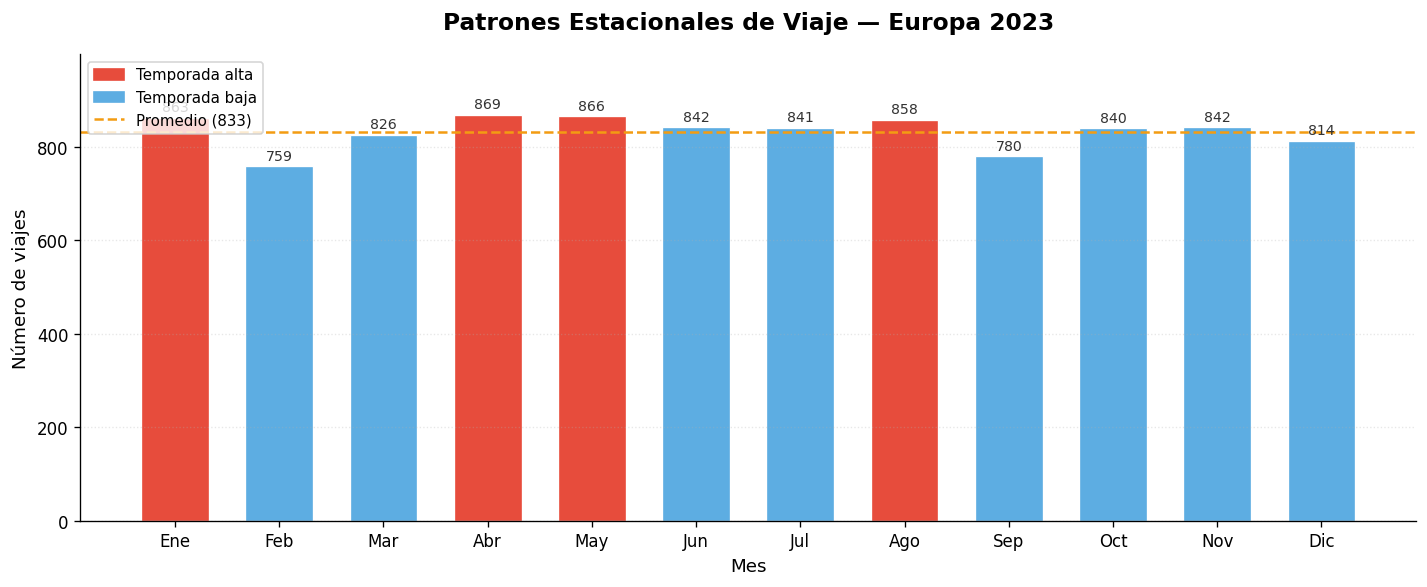


 Insight: los meses en rojo representan la temporada alta de viajes.


In [ ]:
# ── Preparación de datos ──────────────────────────────────────────────────────
orden_meses = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
nombres_es  = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

viajes_mes = (
    df.groupby('mes')
      .size()
      .reindex(range(1, 13), fill_value=0)
      .reset_index()
)
viajes_mes.columns = ['mes', 'n_viajes']
viajes_mes['nombre'] = nombres_es

# ── Colores: temporada alta (≥ percentil 70) vs baja ─────────────────────────
umbral_alto = viajes_mes['n_viajes'].quantile(0.70)
colores = ['#E74C3C' if v >= umbral_alto else '#5DADE2'
           for v in viajes_mes['n_viajes']]

# ── Gráfico ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(viajes_mes['nombre'], viajes_mes['n_viajes'],
              color=colores, width=0.65, edgecolor='white', linewidth=0.8)

# Etiquetas sobre cada barra
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 8,
            f'{int(bar.get_height()):,}',
            ha='center', va='bottom', fontsize=8.5, color='#333333')

# Línea de promedio mensual
promedio = viajes_mes['n_viajes'].mean()
ax.axhline(promedio, color='#F39C12', linestyle='--', linewidth=1.5, label=f'Promedio: {promedio:.0f}')

# Leyenda personalizada
leyenda = [
    mpatches.Patch(color='#E74C3C', label='Temporada alta'),
    mpatches.Patch(color='#5DADE2', label='Temporada baja'),
    plt.Line2D([0], [0], color='#F39C12', linestyle='--', linewidth=1.5, label=f'Promedio ({promedio:.0f})')
]
ax.legend(handles=leyenda, loc='upper left', fontsize=9)

ax.set_title('Patrones Estacionales de Viaje — Europa 2023', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Mes', fontsize=11)
ax.set_ylabel('Número de viajes', fontsize=11)
ax.set_ylim(0, viajes_mes['n_viajes'].max() * 1.15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', alpha=0.3, linestyle=':')

plt.tight_layout()
plt.savefig('grafico_1_patrones_estacionales.png', bbox_inches='tight')
plt.show()
print('\n Insight: los meses en rojo representan la temporada alta de viajes.')

---
## 3. Destinos más populares
> **Gráfico de barras horizontales** — Top 10 ciudades más visitadas

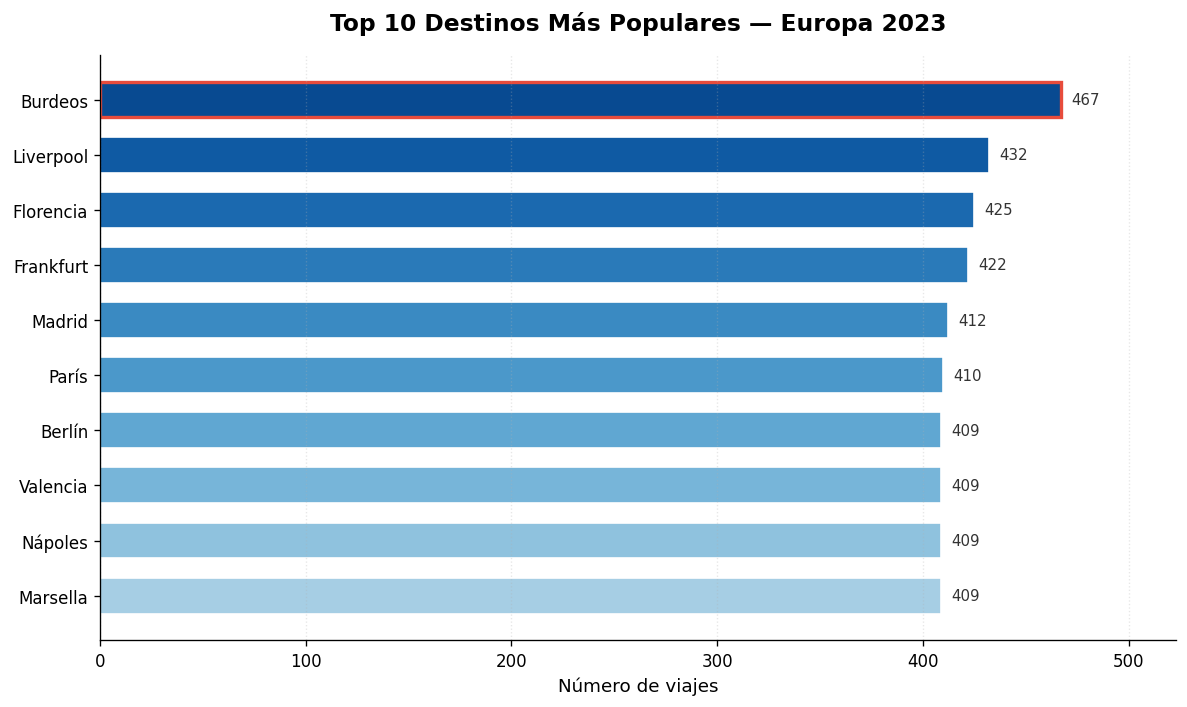

In [ ]:
# ── Preparación de datos ──────────────────────────────────────────────────────
top10 = (
    df['ciudad']
      .value_counts()
      .head(10)
      .sort_values()          # orden ascendente para que la 1.ª quede arriba
      .reset_index()
)
top10.columns = ['ciudad', 'n_viajes']

# Paleta degradada
colores_top = plt.cm.Blues(np.linspace(0.35, 0.9, 10))

# ── Gráfico ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(top10['ciudad'], top10['n_viajes'],
               color=colores_top, edgecolor='white', height=0.65)

# Etiquetas al final de cada barra
for bar in bars:
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            f'{int(bar.get_width()):,}',
            va='center', ha='left', fontsize=9, color='#333333')

# Ciudad #1 resaltada
bars[-1].set_edgecolor('#E74C3C')
bars[-1].set_linewidth(2)

ax.set_title('Top 10 Destinos Más Populares — Europa 2023', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Número de viajes', fontsize=11)
ax.set_ylabel('')
ax.set_xlim(0, top10['n_viajes'].max() * 1.12)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='x', alpha=0.3, linestyle=':')

plt.tight_layout()
plt.savefig('grafico_2_destinos_populares.png', bbox_inches='tight')
plt.show()

---
## 4. Relación entre tipo de alojamiento y gasto diario
> **Diagrama de caja (boxplot)** — distribución del gasto diario por tipo de alojamiento

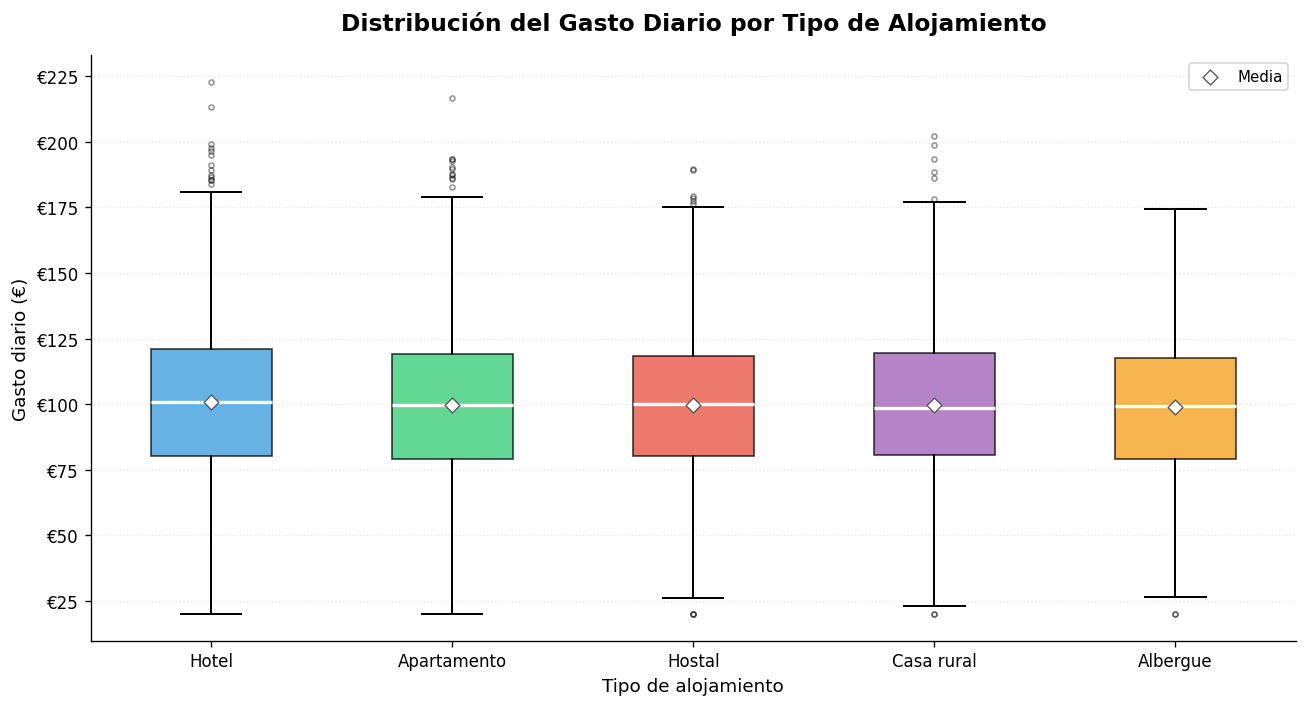


 El rombo (◆) blanco indica la media de cada grupo.


In [ ]:
# ── Preparación de datos ──────────────────────────────────────────────────────
tipos = df['tipo_alojamiento'].value_counts().index.tolist()   # orden por frecuencia
datos_por_tipo = [df.loc[df['tipo_alojamiento'] == t, 'gasto_diario'].values for t in tipos]

colores_box = ['#3498DB', '#2ECC71', '#E74C3C', '#9B59B6', '#F39C12']

# ── Gráfico ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

bp = ax.boxplot(
    datos_por_tipo,
    labels=tipos,
    patch_artist=True,
    notch=False,
    widths=0.5,
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker='o', markersize=3, alpha=0.4)
)

for patch, color in zip(bp['boxes'], colores_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# Medias como marcador adicional
medias = [np.mean(d) for d in datos_por_tipo]
ax.scatter(range(1, len(tipos) + 1), medias,
           color='white', zorder=5, s=40, marker='D',
           edgecolors='#555555', linewidths=0.8, label='Media')

ax.set_title('Distribución del Gasto Diario por Tipo de Alojamiento', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Tipo de alojamiento', fontsize=11)
ax.set_ylabel('Gasto diario (€)', fontsize=11)
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3, linestyle=':')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{x:.0f}'))

plt.tight_layout()
plt.savefig('grafico_3_alojamiento_gasto.png', bbox_inches='tight')
plt.show()
print('\n El rombo (◆) blanco indica la media de cada grupo.')

---
## 5. Satisfacción del cliente por país *(interactivo)*
> **Boxplot interactivo con Plotly** — distribución de valoraciones por país

In [ ]:
# Paleta de colores por país
paleta_pais = {
    'Francia'     : '#3498DB',
    'España'      : '#E74C3C',
    'Alemania'    : '#F1C40F',
    'Reino Unido' : '#2ECC71',
    'Italia'      : '#9B59B6'
}

fig = go.Figure()

for pais, color in paleta_pais.items():
    subset = df[df['pais'] == pais]['valoracion']
    fig.add_trace(go.Box(
        y=subset,
        name=pais,
        marker_color=color,
        boxmean='sd',          # muestra media y desviación estándar
        jitter=0.3,
        pointpos=-1.5,
        boxpoints='outliers',
        hovertemplate=(
            '<b>%{fullData.name}</b><br>'
            'Valoración: %{y}<extra></extra>'
        )
    ))

fig.update_layout(
    title=dict(text='Satisfacción del Cliente por País — Europa 2023',
               font=dict(size=16), x=0.5),
    xaxis_title='País',
    yaxis_title='Valoración (1 – 5)',
    yaxis=dict(tickvals=[1, 2, 3, 4, 5]),
    plot_bgcolor='white',
    paper_bgcolor='white',
    showlegend=False,
    height=500
)
fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=True, gridcolor='#EEEEEE')

fig.show()
fig.write_html('grafico_4_satisfaccion_pais.html')
print('Gráfico guardado como HTML interactivo.')

Gráfico guardado como HTML interactivo.


---
## 6. Duración promedio de estancia por destino *(interactivo)*
> **Gráfico de barras interactivo** — duración promedio por ciudad

In [ ]:
# ── Preparación de datos ──────────────────────────────────────────────────────
duracion_ciudad = (
    df.groupby(['ciudad', 'pais'])['duracion_estancia']
      .mean()
      .round(2)
      .reset_index()
      .sort_values('duracion_estancia', ascending=False)
)

fig = px.bar(
    duracion_ciudad,
    x='ciudad',
    y='duracion_estancia',
    color='pais',
    color_discrete_map=paleta_pais,
    text='duracion_estancia',
    labels={
        'ciudad'            : 'Ciudad',
        'duracion_estancia' : 'Duración promedio (días)',
        'pais'              : 'País'
    },
    title='Duración Promedio de Estancia por Destino — Europa 2023',
    height=520
)

fig.update_traces(
    texttemplate='%{text} d',
    textposition='outside',
    hovertemplate='<b>%{x}</b><br>Promedio: %{y:.1f} días<extra></extra>'
)
fig.update_layout(
    xaxis_tickangle=-40,
    plot_bgcolor='white',
    paper_bgcolor='white',
    title_x=0.5,
    legend_title='País'
)
fig.update_yaxes(showgrid=True, gridcolor='#EEEEEE')

fig.show()
fig.write_html('grafico_5_duracion_estancia.html')
print('Gráfico guardado como HTML interactivo.')

Gráfico guardado como HTML interactivo.


---
## 7. Distribución geográfica de los viajes *(mapa interactivo)*
> **Mapa de burbujas** — color = país · tamaño = duración de la estancia

In [ ]:
fig = px.scatter_mapbox(
    df,
    lat='latitud',
    lon='longitud',
    color='pais',
    size='duracion_estancia',
    hover_name='ciudad',
    hover_data=['fecha', 'tipo_alojamiento', 'gasto_diario', 'valoracion', 'motivo_viaje'],
    zoom=3,
    height=650,
    title='Distribución geográfica de viajes en Europa 2023'
)
fig.update_layout(mapbox_style='open-street-map')
fig.update_layout(margin={'r':0, 't':50, 'l':0, 'b':0})
fig.show()


---
## 8. Resumen de insights

| # | Visualización | Hallazgo clave |
|---|---------------|----------------|
| 1 | Patrones estacionales | Se identifican los meses de mayor y menor actividad turística |
| 2 | Destinos populares | Top 10 ciudades con mayor número de visitas registradas |
| 3 | Alojamiento vs gasto | Se compara la dispersión del gasto según tipo de hospedaje |
| 4 | Satisfacción por país | Comparación interactiva de valoraciones (1–5) entre países |
| 5 | Duración por destino | Ciudades con estancias promedio más largas/cortas |
| 6 | Mapa geográfico | Distribución espacial de viajes con color por país y tamaño por duración |